In [35]:
import earthaccess
import rasterio
from rasterio.plot import show
from rio_cogeo import cog_validate, cog_info
import gen_overviews

ModuleNotFoundError: No module named 'gen_overviews'

In [2]:
earthaccess.login()

In [3]:
# Download data
short_name = 'VCF5KYR'
version = '001'

veg_item_results = earthaccess.search_data(
    short_name=short_name,
    version=version,
    count=1
)

In [8]:
test_data_dir = "./test_data"
veg_files = earthaccess.download(veg_item_results, test_data_dir)
veg_gtiff_filename = f"{test_data_dir}/{veg_files[0]}"

QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 652.51it/s]
PROCESSING TASKS | : 100%|██████████| 1/1 [00:00<?, ?it/s]
COLLECTING RESULTS | : 100%|██████████| 1/1 [00:00<?, ?it/s]


In [13]:
veg_gtiff_filename

'C:\\Users\\darey\\OneDrive - University of Twente\\Documents\\MGEO\\MGEO\\quartile2\\BigGeospatilData\\data_formats\\test_data\\VCF5KYR_1982001_001_2018224204211.tif'

In [10]:
cog_validate(r'C:\Users\darey\OneDrive - University of Twente\Documents\MGEO\MGEO\quartile2\BigGeospatilData\data_formats\test_data\VCF5KYR_1982001_001_2018224204211.tif')

The following warnings were found:
- The file is greater than 512xH or 512xW, it is recommended to include internal overviews



The following errors were found:
- The file is greater than 512xH or 512xW, but is not tiled


(False,
 ['The file is greater than 512xH or 512xW, but is not tiled'],
 ['The file is greater than 512xH or 512xW, it is recommended to include internal overviews'])

In [15]:
veg_gtiff_filename = r'C:\Users\darey\Documents\test_data\VCF5KYR_1982001_001_2018224204211.tif'
veg_cog_filename = veg_gtiff_filename.replace(".tif", "_cog.tif")

!rio cogeo create {veg_gtiff_filename} {veg_cog_filename}

Reading input: C:/Users/darey/Documents/test_data/VCF5KYR_1982001_001_2018224204211.tif

Adding overviews...
Updating dataset tags...
Writing output to: C:\Users\darey\Documents\test_data\VCF5KYR_1982001_001_2018224204211_cog.tif


In [16]:
cog_validate(veg_cog_filename)

(True, [], [])

In [17]:
veg_gtiff_rio = rasterio.open(veg_gtiff_filename)
veg_cog_rio = rasterio.open(veg_cog_filename)

In [21]:
print(veg_gtiff_rio.shape)
print(veg_cog_rio.shape)
print(cog_info(veg_gtiff_filename).IFD)
print(cog_info(veg_cog_filename).IFD)

(3600, 7200)
(3600, 7200)
[IFD(Level=0, Width=7200, Height=3600, Blocksize=(1, 7200), Decimation=0)]
[IFD(Level=0, Width=7200, Height=3600, Blocksize=(512, 512), Decimation=0), IFD(Level=1, Width=3600, Height=1800, Blocksize=(512, 512), Decimation=2), IFD(Level=2, Width=1800, Height=900, Blocksize=(512, 512), Decimation=4), IFD(Level=3, Width=900, Height=450, Blocksize=(512, 512), Decimation=8)]


In [29]:
print(veg_gtiff_rio.overviews(1))
print(veg_cog_rio.overviews(1))

[]
[2, 4, 8]


out height: 1800
out width: 3600


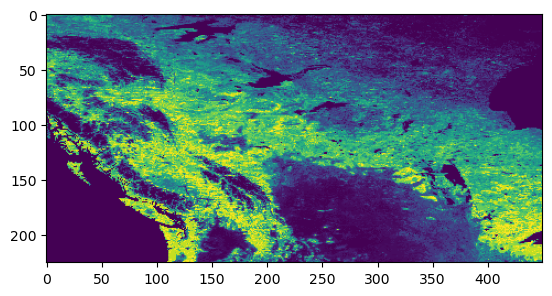

out height: 900
out width: 1800


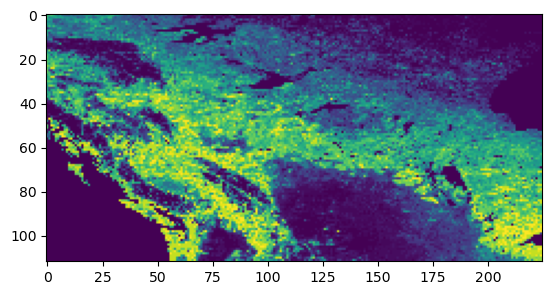

out height: 450
out width: 900


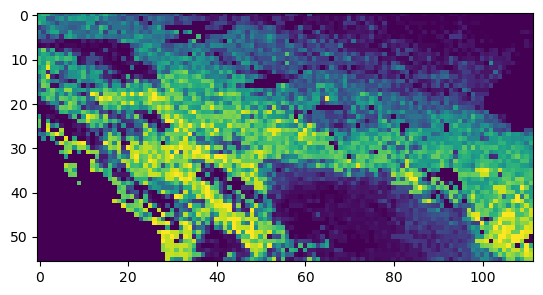

In [24]:
def show_overviews(geotiff):  
    for overview in geotiff.overviews(1):
        out_height = int(geotiff.height // overview)
        out_width = int(geotiff.width // overview)
        print(f"out height: {out_height}")
        print(f"out width: {out_width}")    
        # read first band of file and set shape of new output array
        window_size_height = round(out_height/8)
        window_size_width = round(out_width/8)
        image = veg_cog_rio.read(1, out_shape=(1, out_height, out_width))[
            window_size_height:(window_size_height*2),
            window_size_width:(window_size_width*2),
        ]
        show(image)
        
show_overviews(veg_cog_rio)

In [34]:
import gen_overviews

ModuleNotFoundError: No module named 'gen_overviews'